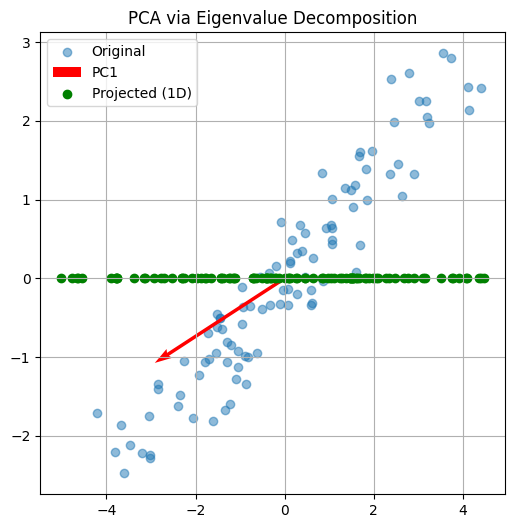

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate some 2D data
np.random.seed(42)
X = np.random.randn(100, 2) @ np.array([[2, 1], [1, 1]])  # Correlated data

# Step 2: Center the data (zero mean)
X_meaned = X - np.mean(X, axis=0)

# Step 3: Compute the covariance matrix
cov_matrix = np.cov(X_meaned, rowvar=False)

# Step 4: Eigenvalue decomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)  # 'eigh' for symmetric matrices

# Step 5: Sort eigenvectors by descending eigenvalues
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

# Step 6: Project data onto the first principal component
k = 1  # Reduce to 1D
principal_components = eigenvectors[:, :k]
X_reduced = X_meaned @ principal_components

# Optional: Plot original and projected data
plt.figure(figsize=(6, 6))
plt.scatter(X_meaned[:, 0], X_meaned[:, 1], alpha=0.5, label="Original")
plt.quiver(0, 0, *principal_components[:, 0], color='r', scale=3, label="PC1")
plt.scatter(X_reduced, np.zeros_like(X_reduced), label="Projected (1D)", color="green")
plt.legend()
plt.title("PCA via Eigenvalue Decomposition")
plt.grid(True)
plt.show()


### IRIS Data before PCA in 4 Dimension

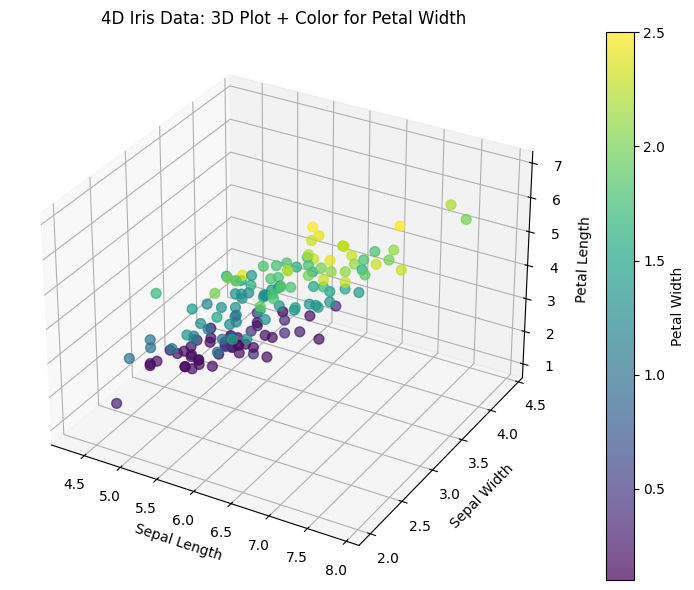

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# Extract the 4 features
x = X[:, 0]  # Sepal length
y_ = X[:, 1] # Sepal width
z = X[:, 2]  # Petal length
color = X[:, 3]  # Petal width

# 3D Plot with 4th dimension as color
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(x, y_, z, c=color, cmap='viridis', s=50, alpha=0.7)
ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')
plt.title("4D Iris Data: 3D Plot + Color for Petal Width")
plt.colorbar(scatter, label='Petal Width')
plt.tight_layout()
plt.show()


### After PCA in 2D

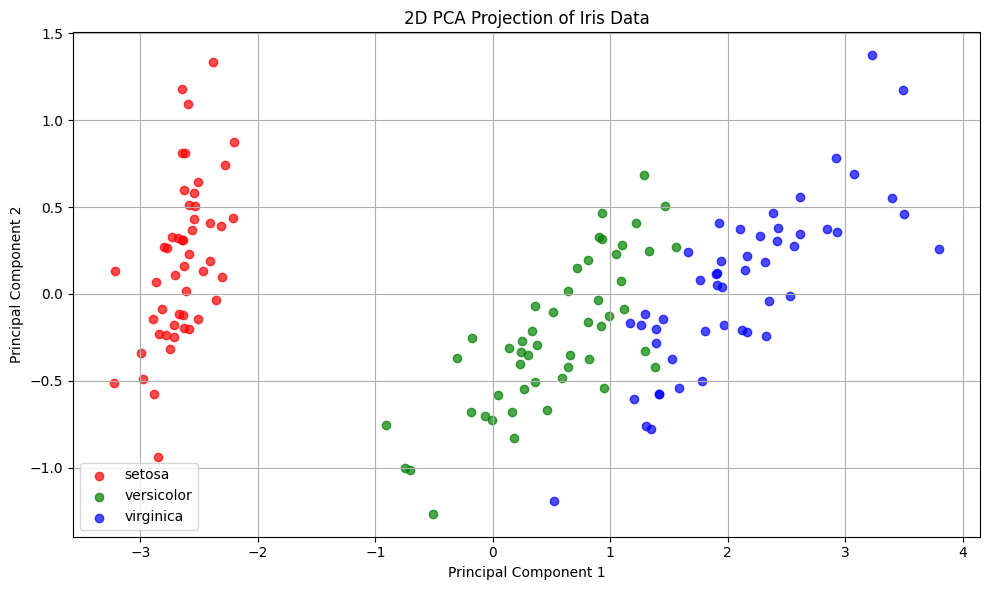

In [3]:
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 2D Plot after PCA
plt.figure(figsize=(10, 6))
for label, color in zip(np.unique(y), ['red', 'green', 'blue']):
    plt.scatter(X_pca[y == label, 0], X_pca[y == label, 1],
                label=target_names[label], alpha=0.7, color=color)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA Projection of Iris Data')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Show PCA Loadings (Feature Contributions to PC1 & PC2)

In [4]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import pandas as pd

# Load the Iris dataset
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

# Fit PCA with 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Get the loadings (how much each feature contributes to each PC)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_names
)

# Print the loadings
print("PCA Loadings (Feature Contributions):")
print(loadings)

# Explained variance
explained_variance = pca.explained_variance_ratio_
print("\nExplained Variance Ratio:")
print(f"PC1: {explained_variance[0]:.2f}")
print(f"PC2: {explained_variance[1]:.2f}")


PCA Loadings (Feature Contributions):
                        PC1       PC2
sepal length (cm)  0.361387  0.656589
sepal width (cm)  -0.084523  0.730161
petal length (cm)  0.856671 -0.173373
petal width (cm)   0.358289 -0.075481

Explained Variance Ratio:
PC1: 0.92
PC2: 0.05


###Interpretation:

PC1 is made mostly from petal length and petal width (high weights).

PC2 is influenced mostly by sepal width.

PC1 alone captures 73% of the variance — which means it contains most of the “information”.


## EVD for PCA

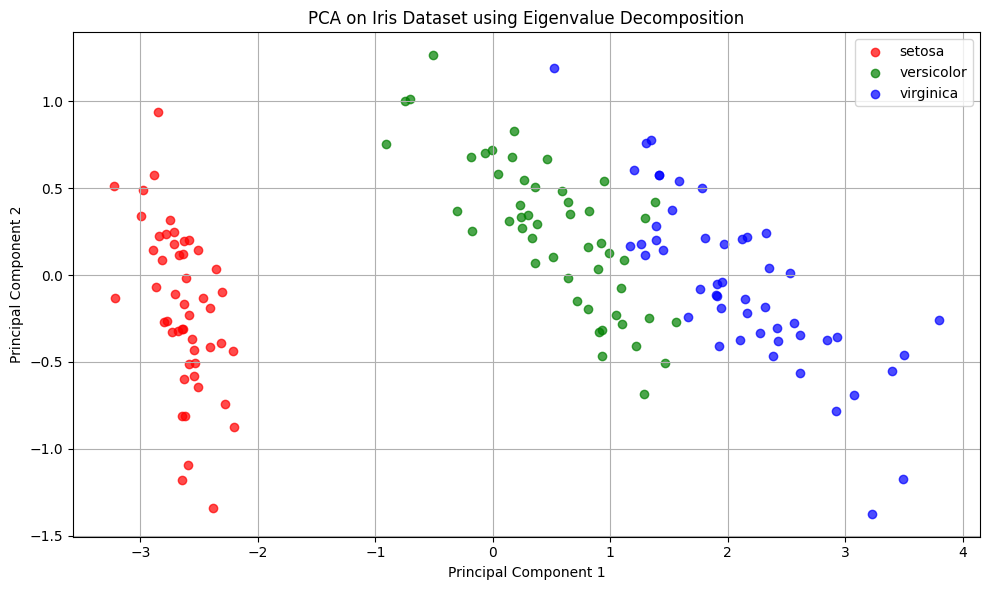

In [1]:
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# Standardize the data (mean = 0)
X_meaned = X - np.mean(X, axis=0)

# Compute the covariance matrix
cov_matrix = np.cov(X_meaned.T)

# Perform Eigenvalue Decomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort the eigenvectors by decreasing eigenvalues
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Project the data onto the top 2 principal components
PC1 = X_meaned @ eigenvectors[:, 0]
PC2 = X_meaned @ eigenvectors[:, 1]

# Plot the result
plt.figure(figsize=(10, 6))
colors = ['red', 'green', 'blue']
for label, color in zip(np.unique(y), colors):
    plt.scatter(PC1[y == label], PC2[y == label], label=target_names[label], color=color, alpha=0.7)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA on Iris Dataset using Eigenvalue Decomposition')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
